# Soft / hard-sphere dilute Bose gas — results analysis

Analysis of an **SS10** equation-of-state sweep (penetrable sphere, $R=10$, scattering length $a=1$,
$N$ bosons, 3D PBC) produced by the `soft_sphere_gas` sweep machinery and stored in
`<root>/soft-hard-bosons/outputs/`.

All numbers are in **paper units** ($\hbar^2/2m=1$, $a=1$, energies in $\hbar^2/2ma^2$), so they drop
straight onto Mazzanti–Polls–Fabrocini (arXiv:cond-mat/0305502). The control parameter is the gas
parameter $x=\rho a^3$.

This notebook only **reads and analyses** an existing DB — it does not train. It reuses the shipped
machinery: `db`, `sweep.load_curve`, `analysis.plot_curve`, `dilute_gas` (Lee-Yang / $4\pi x$ / Eq.31),
and the per-run `history.csv` / `verdict.json` artifacts.

**Corridor that must hold for a converged variational run:** $4\pi x \le E/N \le E_{31}$, with
$E/N \to$ Lee-Yang as $x\to0$.


## 0. Paths & imports

The notebook lives in `<root>/qvarnet/soft_sphere_gas/` and the results live in
`<root>/soft-hard-bosons/outputs/`. Both are derived from the notebook location — edit `ROOT`
below if your layout differs.

In [1]:
from pathlib import Path
import sys, json, math, sqlite3

# --- configurable paths (defaults derived from the notebook's own location) ---
SOFT_DIR = Path.cwd()                       # .../qvarnet/soft_sphere_gas  (run the nb from here)
ROOT     = SOFT_DIR.parent.parent           # .../<root>
DATA_DIR = ROOT / 'soft-bosons' / 'outputs'
DB_PATH  = DATA_DIR / 'pc1.db'
RUNS_DIR = DATA_DIR / 'runs'

# make the bare-module machinery importable (db, sweep, dilute_gas, analysis, point, artifacts)
if str(SOFT_DIR) not in sys.path:
    sys.path.insert(0, str(SOFT_DIR))

assert SOFT_DIR.name == 'soft_sphere_gas', f'run this notebook from soft_sphere_gas/, not {SOFT_DIR}'
assert DB_PATH.exists(), f'DB not found: {DB_PATH}  (edit ROOT/DATA_DIR above)'
print('soft_sphere_gas :', SOFT_DIR)
print('reading results :', DATA_DIR)
print('db              :', DB_PATH)

soft_sphere_gas : /home/pau/PhD/qvarnet/soft_sphere_gas
reading results : /home/pau/PhD/soft-bosons/outputs
db              : /home/pau/PhD/soft-bosons/outputs/pc1.db


In [2]:
%matplotlib inline
# ^ force the inline backend so figures render in the notebook even if MPLBACKEND=Agg is set
#   in the environment (the cluster sets it for headless runs); without this they only savefig.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import db
import sweep
import dilute_gas
import analysis
from point import Potential
import artifacts

# benchmark shorthands (paper units, a=1)
def lower_bound(x):  return 4.0 * math.pi * x                       # Lieb-Yngvason, rigorous
lee_yang = dilute_gas.lee_yang_energy_per_particle                 # Eq.1, x->0 universal limit
eq31     = dilute_gas.first_order_energy_upper_bound               # Eq.31, variational UB

## 1. Load the sweep DB

Every completed run becomes one row. We pull the scalars and unpack the convergence `verdict`
(stationarity, Geweke $z$, split-$\hat R$, epochs) into a tidy frame.

In [3]:
conn = db.connect(str(DB_PATH))
print('queue status:', db.status_counts(conn))

rows = conn.execute("SELECT * FROM runs WHERE status='done' ORDER BY x, N, seed").fetchall()
print(f'{len(rows)} done runs')

def _vget(vj, key, default=None):
    try: return json.loads(vj).get(key, default)
    except (TypeError, ValueError): return default

recs = []
for r in rows:
    recs.append(dict(
        x=r['x'], N=r['N'], seed=r['seed'], L=r['L'],
        e_per_n=r['e_per_n'], err=r['err_per_n'], sigma=r['sigma_e_per_n'],
        acceptance=r['acceptance'], passed=bool(r['passed']),
        upper_bound_db=r['upper_bound'],
        stationary=_vget(r['verdict_json'], 'stationary'),
        geweke_z=_vget(r['verdict_json'], 'geweke_z'),
        split_rhat=_vget(r['verdict_json'], 'split_rhat'),
        epochs=_vget(r['verdict_json'], 'epochs_ran'),
        run_dir=r['run_dir'],
    ))
df = pd.DataFrame(recs).sort_values('x').reset_index(drop=True)
df

queue status: {'done': 90, 'failed': 30}
90 done runs


,x,N,seed,L,e_per_n,err,sigma,acceptance,passed,upper_bound_db,stationary,geweke_z,split_rhat,epochs,run_dir
0,0.000010,32,0,147.361260,0.000125,1.024583e-06,0.000033,0.838061,False,0.000143,True,-1.044280,0.999981,351,runs/SS10_x1.000e-05_N32_s0_d8fbdae0
1,0.000010,32,1,147.361260,0.000124,1.024749e-06,0.000033,0.838164,False,0.000143,True,0.729981,1.000021,351,runs/SS10_x1.000e-05_N32_s1_d8fbdae0
2,0.000010,32,2,147.361260,0.000125,1.026498e-06,0.000033,0.837154,False,0.000143,True,-0.909644,1.000030,351,runs/SS10_x1.000e-05_N32_s2_d8fbdae0
3,0.000010,64,0,185.663553,0.000126,7.283901e-07,0.000023,0.749332,False,0.000143,False,-1.958131,0.999815,351,runs/SS10_x1.000e-05_N64_s0_d8fbdae0
4,0.000010,64,1,185.663553,0.000126,7.274873e-07,0.000023,0.750625,False,0.000143,True,1.874875,0.999803,351,runs/SS10_x1.000e-05_N64_s1_d8fbdae0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.003996,64,1,25.206826,0.055460,3.715893e-05,0.001190,0.637631,False,0.057050,False,3.797922,1.000349,351,runs/SS10_x3.996e-03_N64_s1_d8fbdae0
86,0.003996,64,2,25.206826,0.055419,3.590740e-05,0.001150,0.616622,False,0.057050,False,7.371943,0.999872,351,runs/SS10_x3.996e-03_N64_s2_d8fbdae0
87,0.003996,128,0,31.758611,0.055452,1.576620e-05,0.000505,0.496876,False,0.057050,False,4.539553,1.000169,351,runs/SS10_x3.996e-03_N128_s0_d8fbdae0
88,0.003996,128,1,31.758611,0.055451,1.582873e-05,0.000507,0.496876,False,0.057050,True,0.924420,0.999988,351,runs/SS10_x3.996e-03_N128_s1_d8fbdae0


## 2. Physics corridor check

Same test as `check_db.py`, recomputing the three benchmarks independently from `dilute_gas`:
a run is inside the corridor when $4\pi x - \mathrm{err} \le E/N \le E_{31} + \mathrm{err}$.
`E/4pix` is the ratio plotted in the paper's Fig.1 (the rigorous lower bound is the line at 1).

In [4]:
R = 10.0
V0 = Potential.from_R(R).V0_paper           # V0 fixed by a=1 (Eq.10)

chk = df.copy()
chk['4pix']    = lower_bound(chk['x'])
chk['LeeYang'] = chk['x'].map(lee_yang)
chk['Eq31']    = chk['x'].map(lambda x: eq31(x, V0, R))
chk['E/4pix']  = chk['e_per_n'] / chk['4pix']
chk['E/LY']    = chk['e_per_n'] / chk['LeeYang']
chk['below_lb'] = chk['e_per_n'] < chk['4pix'] - chk['err']
chk['above_ub'] = chk['e_per_n'] > chk['Eq31'] + chk['err']
chk['corridor_ok'] = ~(chk['below_lb'] | chk['above_ub'])

cols = ['x','N','seed','e_per_n','err','4pix','LeeYang','Eq31','E/4pix','E/LY',
        'corridor_ok','stationary','geweke_z','split_rhat','epochs','passed']
n_viol = int((~chk['corridor_ok']).sum())
print(f'corridor violations: {n_viol}/{len(chk)}')
print(f'non-stationary runs: {int((chk["stationary"]==False).sum())}/{len(chk)} '
      f'(verdict.passed: {int(chk["passed"].sum())}/{len(chk)})')
chk[cols].style.format({'e_per_n':'{:.4e}','err':'{:.2e}','4pix':'{:.4e}',
    'LeeYang':'{:.4e}','Eq31':'{:.4e}','E/4pix':'{:.3f}','E/LY':'{:.3f}',
    'geweke_z':'{:.2f}','split_rhat':'{:.4f}'})

corridor violations: 2/90
non-stationary runs: 25/90 (verdict.passed: 0/90)


,x,N,seed,e_per_n,err,4pix,LeeYang,Eq31,E/4pix,E/LY,corridor_ok,stationary,geweke_z,split_rhat,epochs,passed
0,0.000010,32,0,1.2452e-04,1.02e-06,1.2566e-04,1.2758e-04,1.4277e-04,0.991,0.976,False,True,-1.04,1.0000,351,False
1,0.000010,32,1,1.2449e-04,1.02e-06,1.2566e-04,1.2758e-04,1.4277e-04,0.991,0.976,False,True,0.73,1.0000,351,False
2,0.000010,32,2,1.2468e-04,1.03e-06,1.2566e-04,1.2758e-04,1.4277e-04,0.992,0.977,True,True,-0.91,1.0000,351,False
3,0.000010,64,0,1.2618e-04,7.28e-07,1.2566e-04,1.2758e-04,1.4277e-04,1.004,0.989,True,False,-1.96,0.9998,351,False
4,0.000010,64,1,1.2628e-04,7.27e-07,1.2566e-04,1.2758e-04,1.4277e-04,1.005,0.990,True,True,1.87,0.9998,351,False
5,0.000010,64,2,1.2615e-04,7.28e-07,1.2566e-04,1.2758e-04,1.4277e-04,1.004,0.989,True,True,-1.21,1.0000,351,False
6,0.000010,128,0,1.2694e-04,5.16e-07,1.2566e-04,1.2758e-04,1.4277e-04,1.010,0.995,True,True,1.33,1.0002,351,False
7,0.000010,128,1,1.2688e-04,5.15e-07,1.2566e-04,1.2758e-04,1.4277e-04,1.010,0.995,True,True,0.38,1.0001,351,False
8,0.000010,128,2,1.2688e-04,5.16e-07,1.2566e-04,1.2758e-04,1.4277e-04,1.010,0.995,True,True,-1.33,1.0002,351,False
9,0.000019,32,0,2.4407e-04,1.45e-06,2.4450e-04,2.4969e-04,2.7778e-04,0.998,0.977,True,True,1.63,1.0000,351,False


## 3. Equation of state — $E/N$ vs $x$ with benchmarks

`sweep.load_curve` aggregates seeds per $x$. **Note:** every run here has `passed=False`
(the early-stop target was 0, never satisfied — not a physics failure), so we pass
`require_passed=False` to include them. We mark non-stationary points so they aren't read as
physics. Left: paper's Fig.1 axis $E/N \div 4\pi x$; right: absolute $E/N$ (log-log).

curve x-points: 10   seeds/x: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
saved /home/pau/PhD/soft-bosons/outputs/ss10_equation_of_state.png


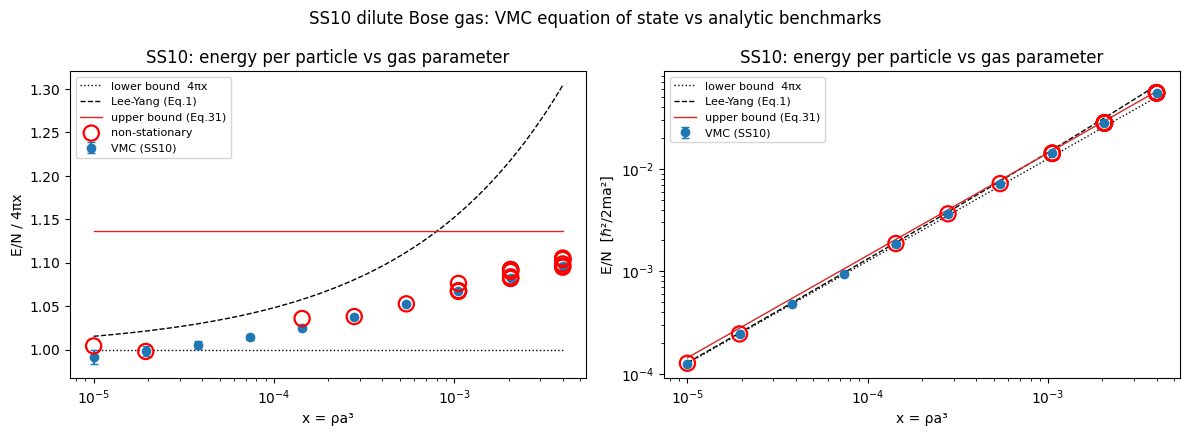

In [5]:
curve = sweep.load_curve(conn, 'SS10', int(df['N'].iloc[0]), require_passed=False)
print('curve x-points:', len(curve['x']), '  seeds/x:', curve['n_per_x'])
pot = Potential.from_R(R)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.4))
analysis.plot_curve(curve, pot, scaled=True,  ax=axL)
analysis.plot_curve(curve, pot, scaled=False, ax=axR)
axR.set_yscale('log')

# overlay the non-stationary points (open red circles) as a 'do not trust yet' flag
bad = chk[chk['stationary'] == False]
if len(bad):
    axL.scatter(bad['x'], bad['e_per_n']/bad['4pix'], s=120, facecolors='none',
                edgecolors='red', linewidths=1.6, zorder=5, label='non-stationary')
    axR.scatter(bad['x'], bad['e_per_n'], s=120, facecolors='none',
                edgecolors='red', linewidths=1.6, zorder=5)
    axL.legend(fontsize=8)
fig.suptitle('SS10 dilute Bose gas: VMC equation of state vs analytic benchmarks')
fig.tight_layout()
fig.savefig(DATA_DIR / 'ss10_equation_of_state.png', dpi=140)
print('saved', DATA_DIR / 'ss10_equation_of_state.png')
display(fig); plt.close(fig)   # display() renders via PNG repr -> works under any backend (incl. Agg)

## 4. Beyond-mean-field: is the LHY $\sqrt{x}$ correction resolved?

Mean field gives $E/N = 4\pi x\,(a_{\rm eff}/a)$, so the ratio $E/N\div4\pi x$ **is** $a_{\rm eff}/a$
if it is flat in $x$. Lee-Yang instead predicts it *rising* as $1+\tfrac{128}{15}\sqrt{x/\pi}$.
Plotting the ratio vs $\sqrt{x}$ separates the two: a horizontal band = mean-field with a renormalised
coupling; an upward slope = genuine LHY. (A flat ratio is the expected signature of a DeepSet ansatz
with **no pairwise Jastrow / correlation hole**.)

weighted-mean ratio  E/N / 4pix = a_eff/a = 1.0695 +/- 0.0001   (over 65 stationary points)
saved ss10_lhy_ratio.png


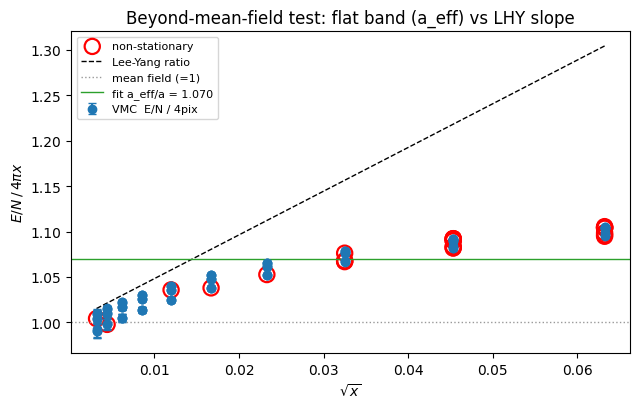

In [6]:
good = chk[chk['stationary'] != False]      # use only stationary points for the fit
ratio = good['E/4pix'].to_numpy()
w = 1.0 / (good['err'].to_numpy() / good['4pix'].to_numpy())**2
a_eff = float(np.sum(w*ratio)/np.sum(w))
a_eff_err = float(np.sqrt(1.0/np.sum(w)))
print(f'weighted-mean ratio  E/N / 4pix = a_eff/a = {a_eff:.4f} +/- {a_eff_err:.4f}'
      f'   (over {len(good)} stationary points)')

fig, ax = plt.subplots(figsize=(6.5, 4.2))
sx = np.sqrt(chk['x'].to_numpy())
ax.errorbar(sx, chk['E/4pix'], yerr=chk['err']/chk['4pix'], fmt='o', color='tab:blue',
            capsize=3, label='VMC  E/N / 4pix')
if len(bad):
    ax.scatter(np.sqrt(bad['x']), bad['e_per_n']/bad['4pix'], s=120, facecolors='none',
               edgecolors='red', linewidths=1.6, label='non-stationary')
xx = np.linspace(chk['x'].min(), chk['x'].max(), 200)
ax.plot(np.sqrt(xx), 1 + (128/15)*np.sqrt(xx/math.pi), 'k--', lw=1, label='Lee-Yang ratio')
ax.axhline(1.0, color='0.6', ls=':', lw=1, label='mean field (=1)')
ax.axhline(a_eff, color='tab:green', lw=1, label=f'fit a_eff/a = {a_eff:.3f}')
ax.set_xlabel(r'$\sqrt{x}$'); ax.set_ylabel(r'$E/N \,/\, 4\pi x$')
ax.set_title('Beyond-mean-field test: flat band (a_eff) vs LHY slope')
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(DATA_DIR / 'ss10_lhy_ratio.png', dpi=140); print('saved ss10_lhy_ratio.png')
display(fig); plt.close(fig)

## 5. Per-run convergence (history.csv)

$E/N$ vs epoch for each run, straight from the artifacts. Non-stationary runs (red) are still
drifting at the last epoch — those points need more epochs (or `sampler='pt'`) before they enter
any physics figure.

saved ss10_convergence.png


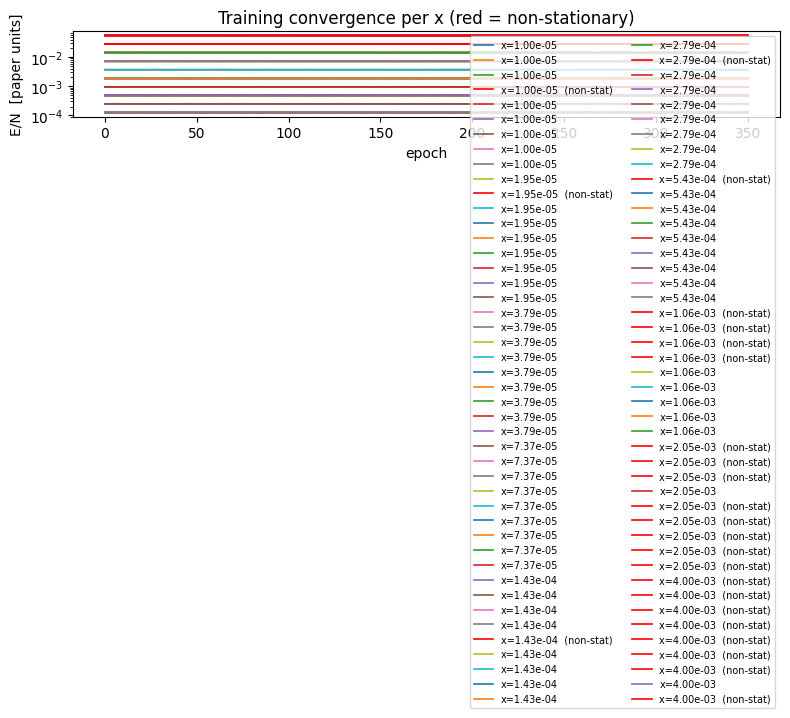

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.6))
for _, row in chk.iterrows():
    rd = RUNS_DIR / Path(row['run_dir']).name
    hist = rd / 'history.csv'
    if not hist.exists():
        print('missing', hist); continue
    h = pd.read_csv(hist)
    nonstat = (row['stationary'] == False)
    ax.plot(h['epoch'], h['e_per_n_paper'], lw=1.2,
            color=('red' if nonstat else None),
            label=f"x={row['x']:.2e}" + ('  (non-stat)' if nonstat else ''))
ax.set_yscale('log')
ax.set_xlabel('epoch'); ax.set_ylabel('E/N  [paper units]')
ax.set_title('Training convergence per x (red = non-stationary)')
ax.legend(fontsize=7, ncol=2); fig.tight_layout()
fig.savefig(DATA_DIR / 'ss10_convergence.png', dpi=140); print('saved ss10_convergence.png')
display(fig); plt.close(fig)

## 6. Thermodynamic limit — $N\to\infty$ extrapolation at fixed $x$

At fixed gas parameter $x$, the finite-box $E/N$ carries a leading $O(1/N)$ finite-size correction,
so a **weighted linear fit of $E/N$ vs $1/N$** extrapolates to the thermodynamic value $E_\infty$ —
the number that lands on the paper's curve. `analysis.extrapolate_thermodynamic` aggregates the
seeds per $(x,N)$ (mean $E/N$, conservative error) and fits per $x$; only $x$ sampled at $\ge 2$
values of $N$ can be extrapolated. (A per-$N$ grid leaves few $x$ overlapping across $N$; the
**aligned** sweep gives all $N$ at every $x$, so this section fills out fully there.)

Below: the per-$x$ fit panels ($E/N$ vs $1/N$, red square $= 1/N\to0$), then $E_\infty(x)$ on the
benchmark corridor (grey $=$ the finite-$N$ points it was extrapolated from).

N ladder = [32, 64, 128];  extrapolated 10 x-point(s) with >=2 N


,x,n_N,E_inf,E_inf_err,slope_per_1/N,E_inf/4pix,E_inf/LY
0,1.000e-05,3,1.27691e-04,7.56e-07,-9.882e-05,1.016,1.001
1,1.946e-05,3,2.49642e-04,1.06e-06,-1.788e-04,1.021,1.000
2,3.786e-05,3,4.88834e-04,1.49e-06,-3.390e-04,1.028,0.998
3,7.366e-05,3,9.58556e-04,2.10e-06,-6.329e-04,1.036,0.995
4,1.433e-04,3,1.88252e-03,2.98e-06,-1.161e-03,1.045,0.988
5,2.788e-04,3,3.70317e-03,4.28e-06,-2.090e-03,1.057,0.978
6,5.425e-04,3,7.29100e-03,6.35e-06,-3.642e-03,1.069,0.962
7,1.056e-03,3,1.43608e-02,9.88e-06,-6.179e-03,1.083,0.936
8,2.054e-03,3,2.82626e-02,1.66e-05,-9.411e-03,1.095,0.899
9,3.996e-03,3,5.55550e-02,3.14e-05,-1.185e-02,1.106,0.848


saved /home/pau/PhD/soft-bosons/outputs/ss10_extrapolation.png


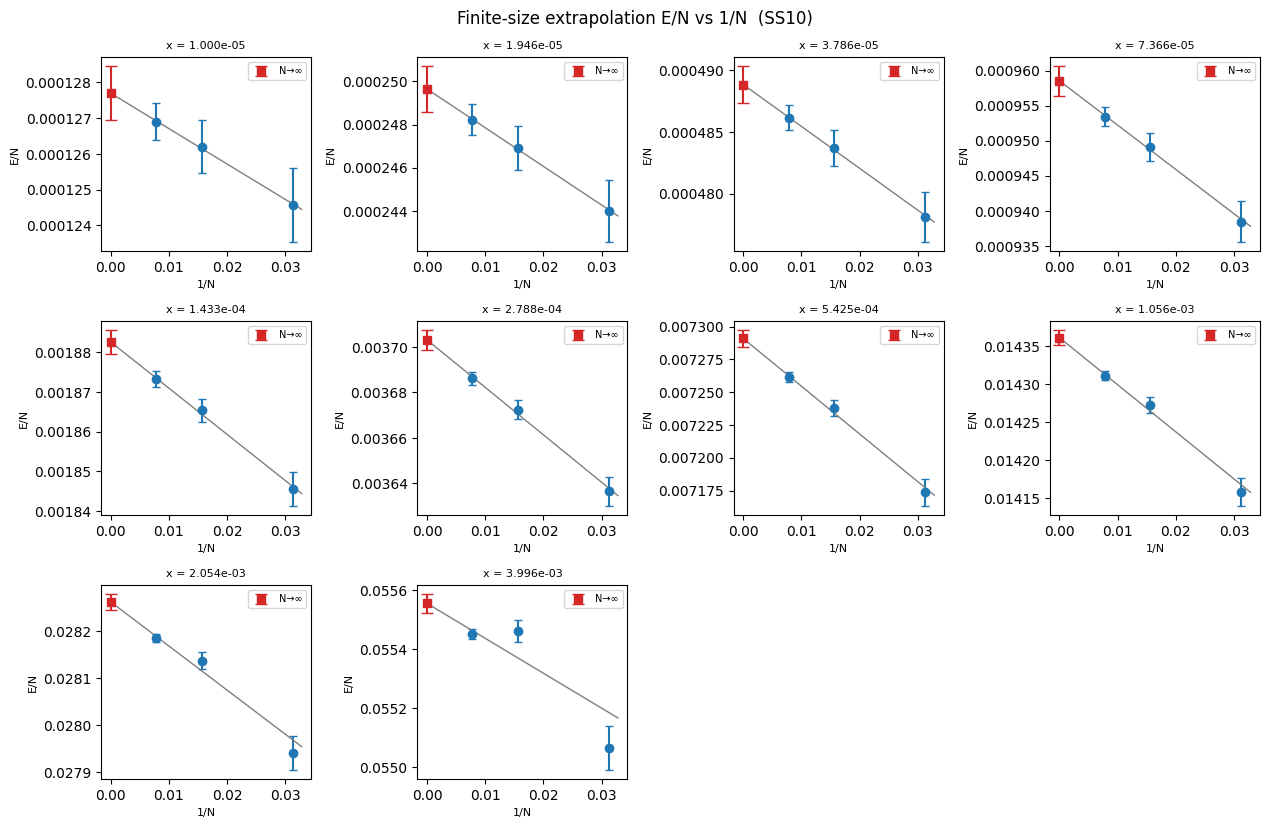

In [8]:
N_list = sorted(int(n) for n in df['N'].unique())
fits = analysis.extrapolate_thermodynamic(conn, 'SS10', N_list, require_passed=False)
print(f'N ladder = {N_list};  extrapolated {len(fits)} x-point(s) with >=2 N')

if fits:
    ext = pd.DataFrame([
        {'x': x, 'n_N': f['n_points'], 'E_inf': f['e_inf'], 'E_inf_err': f['e_inf_err'],
         'slope_per_1/N': f['slope'],
         'E_inf/4pix': f['e_inf']/lower_bound(x), 'E_inf/LY': f['e_inf']/lee_yang(x)}
        for x, f in sorted(fits.items())])
    display(ext.style.format({'x':'{:.3e}','E_inf':'{:.5e}','E_inf_err':'{:.2e}',
        'slope_per_1/N':'{:+.3e}','E_inf/4pix':'{:.3f}','E_inf/LY':'{:.3f}'}))
    # one panel per x: E/N vs 1/N with the weighted fit line and the 1/N->0 extrapolate (red square)
    fig = analysis.plot_extrapolations(fits, pot, scaled=False, save=DATA_DIR / 'ss10_extrapolation.png')
    display(fig); plt.close(fig)

saved ss10_eos_thermodynamic.png


/tmp/ipykernel_106775/3702244101.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([1, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35])


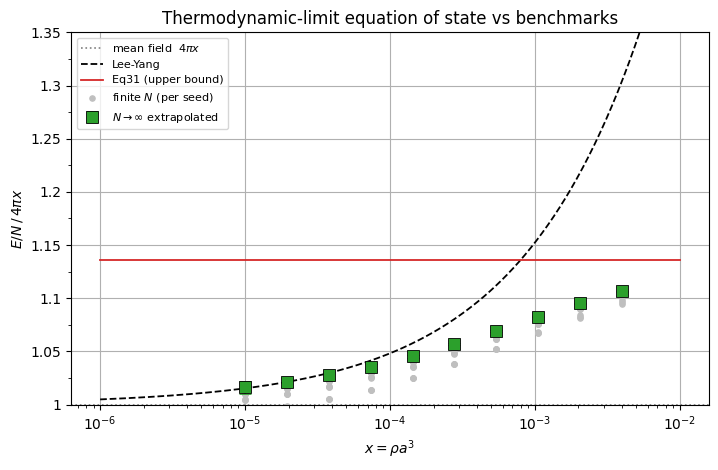

In [15]:
# E_inf(x) on the equation-of-state axis (E/N / 4pix) vs the analytic benchmarks.
# Benchmark curves span the FULL data x-range; green = N->inf extrapolated (where >=2 N exist).
# x_all = np.sort(chk['x'].unique())
x_all = np.array([1e-6, 1e-2])
xx = np.geomspace(x_all.min(), x_all.max(), 300)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.axhline(1.0, color='0.5', ls=':', lw=1.2, label=r'mean field  $4\pi x$')
ax.plot(xx, [lee_yang(x) / lower_bound(x) for x in xx], 'k--', lw=1.3, label='Lee-Yang')
ax.plot(xx, [eq31(x, V0, R) / lower_bound(x) for x in xx], color='tab:red', lw=1.3,
        label='Eq31 (upper bound)')
ax.scatter(chk['x'], chk['E/4pix'], s=14, color='0.75', zorder=2, label=r'finite $N$ (per seed)')
if fits:
    xs_e = np.array(sorted(fits))
    e_inf = np.array([fits[x]['e_inf'] for x in xs_e])
    e_inf_err = np.array([fits[x]['e_inf_err'] for x in xs_e])
    ax.errorbar(xs_e, e_inf / lower_bound(xs_e), yerr=e_inf_err / lower_bound(xs_e), fmt='s',
                color='tab:green', mec='k', mew=0.6, ms=8, capsize=4, zorder=6,
                label=r'$N\to\infty$ extrapolated')
ax.set_xscale('log')
ax.set_xlabel(r'$x = \rho a^3$')
ax.set_ylabel(r'$E/N \,/\, 4\pi x$')
ax.set_title('Thermodynamic-limit equation of state vs benchmarks')
ax.legend(fontsize=8, loc='best')
fig.tight_layout()
fig.savefig(DATA_DIR / 'ss10_eos_thermodynamic.png', dpi=140)
ax.set_yticklabels([1, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35])
from matplotlib import ticker as mticker
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
plt.grid()
plt.ylim(1.0, 1.35)
print('saved ss10_eos_thermodynamic.png')
display(fig); plt.close(fig)

## 7. Findings & next steps

*(auto-summary from the cells above; edit after inspecting the figures)*

In [10]:
n_done = len(chk); n_stat = int((chk['stationary'] != False).sum())
print('SS10 sweep summary')
print('-'*60)
print(f'points (done)        : {n_done}   x in [{chk["x"].min():.2e}, {chk["x"].max():.2e}]')
print(f'inside corridor      : {int(chk["corridor_ok"].sum())}/{n_done}')
print(f'stationary           : {n_stat}/{n_done}')
print(f'weighted-mean E/4pix : {a_eff:.4f} +/- {a_eff_err:.4f}  (only meaningful if ~flat in x)')
print()
print('non-stationary points to re-run (more epochs / sampler=pt):')
for _, b in chk[chk['stationary']==False].iterrows():
    print(f"   x={b['x']:.3e}  geweke_z={b['geweke_z']:.2f}  epochs={b['epochs']}")
print()
print('Interpretation:')
print(' - E/N stays inside [4pix, Eq31] -> variationally consistent.')
print(' - With the soft-core Jastrow ON, E/N tracks Lee-Yang at low x (the 2-body correlation')
print('   hole is captured); compare the N->inf extrapolation (section 6) to DMC / the paper curve.')
print(' - At low x mean-field ~ Lee-Yang ~ 4pix (within ~1-2%), so the corridor is a WEAK test')
print('   there; the real validation is DMC and the extrapolated E_inf(x) landing on the curve.')
print(' - Beyond-mean-field/3-body rides on the DeepSet (matters more at higher x); cross-check g(r).')

SS10 sweep summary
------------------------------------------------------------
points (done)        : 90   x in [1.00e-05, 4.00e-03]
inside corridor      : 88/90
stationary           : 65/90
weighted-mean E/4pix : 1.0695 +/- 0.0001  (only meaningful if ~flat in x)

non-stationary points to re-run (more epochs / sampler=pt):
   x=1.000e-05  geweke_z=-1.96  epochs=351
   x=1.946e-05  geweke_z=1.48  epochs=351
   x=1.433e-04  geweke_z=2.17  epochs=351
   x=2.788e-04  geweke_z=2.68  epochs=351
   x=5.425e-04  geweke_z=1.18  epochs=351
   x=1.056e-03  geweke_z=2.84  epochs=351
   x=1.056e-03  geweke_z=5.85  epochs=351
   x=1.056e-03  geweke_z=4.33  epochs=351
   x=1.056e-03  geweke_z=1.52  epochs=351
   x=2.054e-03  geweke_z=7.41  epochs=351
   x=2.054e-03  geweke_z=6.31  epochs=351
   x=2.054e-03  geweke_z=2.78  epochs=351
   x=2.054e-03  geweke_z=3.85  epochs=351
   x=2.054e-03  geweke_z=1.52  epochs=351
   x=2.054e-03  geweke_z=1.00  epochs=351
   x=2.054e-03  geweke_z=1.86  epochs=351
